**Which days have data**
****
reading + flattening + daily availability summary
****
This code performs the initial preprocessing of the raw detector JSON files for all available LSAs. It reads the files from the specified folders, handles both March and April filename formats, and converts the nested JSON structure into a flat long-format table. During this step, different types of missing data are distinguished, including completely empty days (timeFrames: []), timestamps without detector entries (detectors: []), and timestamps with valid detector measurements. In addition, UTC timestamps are converted to local Berlin time. The code then creates daily availability summaries for each LSA, indicating whether a day is fully available, partially available, or empty. Finally, the processed raw table and summary tables are saved as CSV files for the next stages of analysis.
****
As part of the preprocessing, I evaluated the temporal availability of detector data for each LSA on a daily basis. The raw JSON files were parsed and classified into full days, partial days, and empty days, depending on the number of 15-minute intervals with valid detector measurements. In addition to this daily classification, I assessed the maximum continuous period with available data within each day. This step is important because, for LSTM-based forecasting, a day does not necessarily need to contain complete 24-hour coverage; rather, it must provide sufficiently long continuous sequences for sequence construction. Therefore, partial days with long uninterrupted measurement periods can still be used for model development, whereas highly fragmented days with many gaps are less suitable.
****
partial day is usable if it has at least 16 continuous bins
that means 4 continuous hours
****

In [2]:
from pathlib import Path
import json
import pandas as pd
import numpy as np

# ============================================================
# SETTINGS
# ============================================================

DATA_DIR = Path(r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\detector_data_aktuell")
OUT_DIR = Path(r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\LSTM_Model")
OUT_DIR.mkdir(parents=True, exist_ok=True)

LSA_FOLDERS = ["LD-LSA1", "LD-LSA8", "LD-LSA9", "LD-LSA10", "LD-LSA16"]
TIMEZONE_LOCAL = "Europe/Berlin"
EXPECTED_BINS_PER_DAY = 96  # 24h * 4 bins/hour for 15-min data

RAW_LONG_CSV = OUT_DIR / "raw_detector_long.csv"
DAY_SUMMARY_CSV = OUT_DIR / "day_availability_summary.csv"
FILE_SUMMARY_CSV = OUT_DIR / "file_summary.csv"
AVAILABLE_DAYS_CSV = OUT_DIR / "available_days_by_lsa.csv"
COMMON_DAYS_CSV = OUT_DIR / "common_days_summary.csv"

# ============================================================
# HELPERS
# ============================================================

def parse_json_file(path: Path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def classify_file_name(path: Path):
    """
    Handles:
    - 2026-03-01.json
    - 2026-04-01_0000.json
    """
    return path.stem[:10]

def safe_get(dct, keys, default=np.nan):
    cur = dct
    for k in keys:
        if isinstance(cur, dict) and k in cur:
            cur = cur[k]
        else:
            return default
    return cur

# ============================================================
# READ AND FLATTEN
# ============================================================

rows = []
file_rows = []

for lsa in LSA_FOLDERS:
    lsa_dir = DATA_DIR / lsa
    if not lsa_dir.exists():
        print(f"Folder not found: {lsa_dir}")
        continue

    json_files = sorted(lsa_dir.glob("*.json"))
    print(f"{lsa}: {len(json_files)} json files found")

    for path in json_files:
        try:
            data = parse_json_file(path)
        except Exception as e:
            file_rows.append({
                "lsa": lsa,
                "file_name": path.name,
                "date_from_name": classify_file_name(path),
                "read_ok": False,
                "error": str(e),
                "n_timeframes": np.nan,
                "empty_timeframes_list": np.nan
            })
            continue

        timeframes = data.get("timeFrames", [])

        file_rows.append({
            "lsa": lsa,
            "file_name": path.name,
            "date_from_name": classify_file_name(path),
            "read_ok": True,
            "error": "",
            "n_timeframes": len(timeframes),
            "empty_timeframes_list": len(timeframes) == 0
        })

        for tf in timeframes:
            ts_utc = tf.get("timestamp")
            detectors = tf.get("detectors", [])

            # timeframe exists but no detector data
            if len(detectors) == 0:
                rows.append({
                    "lsa": lsa,
                    "source_file": path.name,
                    "date_from_name": classify_file_name(path),
                    "timestamp_utc": ts_utc,
                    "detector_id": np.nan,
                    "count": np.nan,
                    "occupancy": np.nan,
                    "speed": np.nan,
                    "confidence": np.nan,
                    "timeframe_exists": True,
                    "detector_data_exists": False
                })
                continue

            # timeframe with detector data
            for det in detectors:
                rows.append({
                    "lsa": lsa,
                    "source_file": path.name,
                    "date_from_name": classify_file_name(path),
                    "timestamp_utc": ts_utc,
                    "detector_id": safe_get(det, ["id"]),
                    "count": safe_get(det, ["reading", "count", "value"]),
                    "occupancy": safe_get(det, ["reading", "occupancy", "value"]),
                    "speed": safe_get(det, ["reading", "speed", "value"]),
                    "confidence": safe_get(det, ["confidence"]),
                    "timeframe_exists": True,
                    "detector_data_exists": True
                })

raw_df = pd.DataFrame(rows)
file_df = pd.DataFrame(file_rows)

# ============================================================
# TIMESTAMP HANDLING
# ============================================================

if not raw_df.empty:
    raw_df["timestamp_utc"] = pd.to_datetime(raw_df["timestamp_utc"], utc=True, errors="coerce")
    raw_df["timestamp_berlin"] = raw_df["timestamp_utc"].dt.tz_convert(TIMEZONE_LOCAL)
    raw_df["date_berlin"] = raw_df["timestamp_berlin"].dt.strftime("%Y-%m-%d")
    raw_df["time_berlin"] = raw_df["timestamp_berlin"].dt.time

# ============================================================
# FILE SUMMARY
# ============================================================

file_df.to_csv(FILE_SUMMARY_CSV, index=False, encoding="utf-8-sig")

# ============================================================
# DAY-LEVEL SUMMARY
# ============================================================

day_file_base = file_df[["lsa", "file_name", "date_from_name", "read_ok", "n_timeframes", "empty_timeframes_list"]].copy()
day_file_base = day_file_base.rename(columns={"date_from_name": "date_str"})

if not raw_df.empty:
    # one row per (lsa, timestamp) to evaluate whether that 15-min bin has any detector data
    tf_level = (
        raw_df.groupby(["lsa", "timestamp_utc", "date_berlin"], as_index=False)
        .agg(
            detector_data_exists=("detector_data_exists", "max"),
            n_detector_records=("detector_id", lambda s: s.notna().sum()),
            timestamp_berlin=("timestamp_berlin", "first")
        )
    )

    day_stats = (
        tf_level.groupby(["lsa", "date_berlin"], as_index=False)
        .agg(
            n_timeframes_present=("timestamp_utc", "nunique"),
            n_timeframes_with_detector_data=("detector_data_exists", lambda s: int(s.sum())),
            n_detector_records=("n_detector_records", "sum"),
            first_timestamp=("timestamp_berlin", "min"),
            last_timestamp=("timestamp_berlin", "max"),
        )
        .rename(columns={"date_berlin": "date_str"})
    )
else:
    day_stats = pd.DataFrame(columns=[
        "lsa", "date_str", "n_timeframes_present", "n_timeframes_with_detector_data",
        "n_detector_records", "first_timestamp", "last_timestamp"
    ])

day_summary = day_file_base.merge(day_stats, on=["lsa", "date_str"], how="left")
day_summary["expected_bins_per_day"] = EXPECTED_BINS_PER_DAY

day_summary["coverage_ratio"] = (
    day_summary["n_timeframes_with_detector_data"].fillna(0) / day_summary["expected_bins_per_day"]
)

day_summary["day_status"] = np.select(
    [
        day_summary["read_ok"] == False,
        day_summary["empty_timeframes_list"] == True,
        day_summary["n_timeframes_with_detector_data"].fillna(0) == 0,
        day_summary["n_timeframes_with_detector_data"].fillna(0) < EXPECTED_BINS_PER_DAY,
        day_summary["n_timeframes_with_detector_data"].fillna(0) >= EXPECTED_BINS_PER_DAY
    ],
    [
        "read_error",
        "empty_day",
        "timeframes_but_no_detector_data",
        "partial_day",
        "full_day"
    ],
    default="unknown"
)

# ============================================================
# PARTIAL-DAY USABILITY CHECK
# ============================================================

if not raw_df.empty:
    tf_level["date_str"] = tf_level["date_berlin"]

    usable_rows = []

    for (lsa, date_str), grp in tf_level.groupby(["lsa", "date_str"]):
        grp = grp.sort_values("timestamp_utc").copy()
        grp["has_data"] = grp["detector_data_exists"].astype(int)

        max_continuous_bins = 0
        current_run = 0

        for v in grp["has_data"]:
            if v == 1:
                current_run += 1
                max_continuous_bins = max(max_continuous_bins, current_run)
            else:
                current_run = 0

        usable_rows.append({
            "lsa": lsa,
            "date_str": date_str,
            "max_continuous_bins_with_data": max_continuous_bins,
            "max_continuous_hours_with_data": max_continuous_bins * 0.25
        })

    usable_df = pd.DataFrame(usable_rows)
    day_summary = day_summary.merge(usable_df, on=["lsa", "date_str"], how="left")
else:
    day_summary["max_continuous_bins_with_data"] = np.nan
    day_summary["max_continuous_hours_with_data"] = np.nan

# Suggested usability flag for later modeling
# Example rule:
# - full_day always usable
# - partial_day usable if there are at least 16 continuous bins = 4 hours
day_summary["model_usability"] = np.select(
    [
        day_summary["day_status"] == "full_day",
        (day_summary["day_status"] == "partial_day") & (day_summary["max_continuous_bins_with_data"].fillna(0) >= 16),
        day_summary["day_status"] == "partial_day"
    ],
    [
        "usable",
        "usable_partial",
        "not_recommended"
    ],
    default="not_usable"
)

day_summary.to_csv(DAY_SUMMARY_CSV, index=False, encoding="utf-8-sig")
raw_df.to_csv(RAW_LONG_CSV, index=False, encoding="utf-8-sig")

# ============================================================
# AVAILABLE DAYS PER LSA
# ============================================================

available_days = day_summary[
    day_summary["model_usability"].isin(["usable", "usable_partial"])
].copy()

available_days = available_days[[
    "lsa", "date_str", "day_status", "coverage_ratio",
    "max_continuous_bins_with_data", "max_continuous_hours_with_data",
    "model_usability"
]].sort_values(["lsa", "date_str"])

available_days.to_csv(AVAILABLE_DAYS_CSV, index=False, encoding="utf-8-sig")

# ============================================================
# COMMON DAYS ACROSS LSAs
# ============================================================

available_sets = {
    lsa: set(available_days.loc[available_days["lsa"] == lsa, "date_str"])
    for lsa in LSA_FOLDERS
}

common_rows = []

# all LSAs
all_common = set.intersection(*available_sets.values()) if available_sets else set()
for d in sorted(all_common):
    common_rows.append({
        "group_name": "ALL_5_LSAS",
        "date_str": d
    })

# measured corridor LSAs you care most about
measured_lsas = ["LD-LSA1", "LD-LSA9", "LD-LSA10", "LD-LSA16"]
measured_sets = [available_sets[x] for x in measured_lsas if x in available_sets]
common_measured = set.intersection(*measured_sets) if measured_sets else set()
for d in sorted(common_measured):
    common_rows.append({
        "group_name": "MEASURED_4_LSAS",
        "date_str": d
    })

common_df = pd.DataFrame(common_rows)
common_df.to_csv(COMMON_DAYS_CSV, index=False, encoding="utf-8-sig")

# ============================================================
# PRINT SUMMARY
# ============================================================

print("\nSaved:")
print(RAW_LONG_CSV)
print(DAY_SUMMARY_CSV)
print(FILE_SUMMARY_CSV)
print(AVAILABLE_DAYS_CSV)
print(COMMON_DAYS_CSV)

print("\nDay status counts:")
print(day_summary["day_status"].value_counts(dropna=False))

print("\nModel usability counts:")
print(day_summary["model_usability"].value_counts(dropna=False))

print("\nAvailable usable days per LSA:")
print(available_days.groupby("lsa")["date_str"].nunique())

print("\nCommon usable days across measured 4 LSAs (LSA1, LSA9, LSA10, LSA16):")
print(len(common_measured))
print(sorted(common_measured))

print("\nCommon usable days across all 5 LSAs:")
print(len(all_common))
print(sorted(all_common))

LD-LSA1: 47 json files found
LD-LSA8: 47 json files found
LD-LSA9: 47 json files found
LD-LSA10: 47 json files found
LD-LSA16: 47 json files found

Saved:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\LSTM_Model\raw_detector_long.csv
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\LSTM_Model\day_availability_summary.csv
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\LSTM_Model\file_summary.csv
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\LSTM_Model\available_days_by_lsa.csv
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\LSTM_Model\common_days_summary.csv

Day status counts:
day_status
partial_day    137
full_day        54
empty_day       44
Name: count, dtype: int64

Model usability counts:
model_usability
usable_partial     130
usable              54
not_usable          44
not_recommended      7
Name: count, dtype: int64

Available usable days per LSA:
lsa
LD-LSA1     40
LD-LSA10    47
LD-LSA16    43
LD-LSA8      7
LD-LSA9     47
Name: date_str, dtype: int64

Common usable days across measured 4 LSAs (LSA1, LSA9

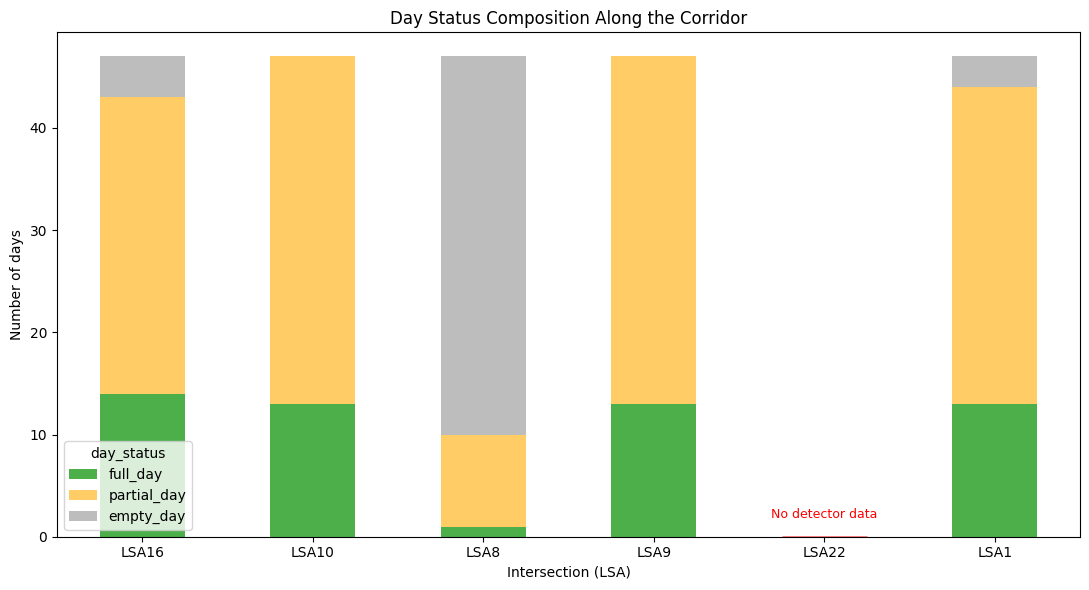

Saved figure:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\LSTM_Model\lsa_day_status_stacked_chart_corridor_order.png


In [6]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# PATHS
# ============================================================

BASE_DIR = Path(r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\LSTM_Model")
DAY_SUMMARY_CSV = BASE_DIR / "day_availability_summary.csv"
OUT_FIG_PNG = BASE_DIR / "lsa_day_status_stacked_chart_corridor_order.png"

# ============================================================
# LOAD
# ============================================================

day_summary = pd.read_csv(DAY_SUMMARY_CSV)

status_table = (
    day_summary.groupby(["lsa", "day_status"])
    .size()
    .unstack(fill_value=0)
)

# keep only common columns if they exist
wanted_cols = ["full_day", "partial_day", "empty_day"]
existing_cols = [c for c in wanted_cols if c in status_table.columns]
status_table = status_table[existing_cols]

# ============================================================
# ARRANGE CORRIDOR ORDER
# ============================================================

corridor_order = ["LD-LSA16", "LD-LSA10", "LD-LSA8", "LD-LSA9", "LD-LSA22", "LD-LSA1"]

# add missing LSA22 manually with zero values
for lsa in corridor_order:
    if lsa not in status_table.index:
        status_table.loc[lsa] = 0

# reorder exactly as corridor
status_table = status_table.reindex(corridor_order)

# make sure all 3 columns exist
for col in ["full_day", "partial_day", "empty_day"]:
    if col not in status_table.columns:
        status_table[col] = 0

status_table = status_table[["full_day", "partial_day", "empty_day"]]

# ============================================================
# PLOT
# ============================================================

fig, ax = plt.subplots(figsize=(11, 6))

# normal stacked bars
status_table.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=["#4daf4a", "#ffcc66", "#bdbdbd"]  # green, orange, gray
)

# make LSA22 red manually
lsa22_idx = corridor_order.index("LD-LSA22")
for container in ax.containers:
    if len(container) > lsa22_idx:
        container[lsa22_idx].set_color("red")

ax.set_title("Day Status Composition Along the Corridor")
ax.set_xlabel("Intersection (LSA)")
ax.set_ylabel("Number of days")
ax.set_xticklabels(["LSA16", "LSA10", "LSA8", "LSA9", "LSA22", "LSA1"], rotation=0)

# small note for LSA22
ax.text(
    lsa22_idx,
    1.5,
    "No detector data",
    ha="center",
    va="bottom",
    fontsize=9,
    color="red"
)

plt.tight_layout()
plt.savefig(OUT_FIG_PNG, dpi=200, bbox_inches="tight")
plt.show()

print("Saved figure:")
print(OUT_FIG_PNG)

****
The availability analysis indicates clear differences in usable detector data across the intersections. LSA10 and LSA9 provide the highest number of usable days, followed by LSA16 and LSA1. By contrast, LSA8 shows substantially lower data availability and is therefore not considered suitable for the initial LSTM modeling framework. Since the forecasting model relies on continuous temporal sequences rather than complete 24-hour coverage, both fully available days and sufficiently continuous partial days are included in the usability assessment.
****

In [3]:
import pandas as pd
import numpy as np
from pathlib import Path

# ============================================================
# PATHS
# ============================================================

OUT_DIR = Path(r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\LSTM_Model")

RAW_LONG_CSV = OUT_DIR / "raw_detector_long.csv"
DETECTOR_SUMMARY_CSV = OUT_DIR / "detector_summary_by_lsa.csv"

# ============================================================
# LOAD
# ============================================================

raw_df = pd.read_csv(RAW_LONG_CSV)

# keep only rows with actual detector measurements
det_df = raw_df[raw_df["detector_data_exists"] == True].copy()

# make detector_id integer-like where possible
det_df["detector_id"] = pd.to_numeric(det_df["detector_id"], errors="coerce")

# ============================================================
# DETECTOR SUMMARY
# ============================================================

detector_summary = (
    det_df.groupby(["lsa", "detector_id"], as_index=False)
    .agg(
        n_records=("detector_id", "size"),
        n_unique_timestamps=("timestamp_utc", "nunique"),
        first_timestamp=("timestamp_berlin", "min"),
        last_timestamp=("timestamp_berlin", "max"),
        mean_count=("count", "mean"),
        median_count=("count", "median"),
        max_count=("count", "max"),
        zero_count_share=("count", lambda s: (pd.to_numeric(s, errors="coerce").fillna(0) == 0).mean()),
        mean_occupancy=("occupancy", "mean"),
        median_occupancy=("occupancy", "median"),
        max_occupancy=("occupancy", "max"),
        zero_occupancy_share=("occupancy", lambda s: (pd.to_numeric(s, errors="coerce").fillna(0) == 0).mean())
    )
    .sort_values(["lsa", "detector_id"])
)

detector_summary.to_csv(DETECTOR_SUMMARY_CSV, index=False, encoding="utf-8-sig")

print("Saved:")
print(DETECTOR_SUMMARY_CSV)

print("\nDetector counts by LSA:")
print(detector_summary.groupby("lsa")["detector_id"].nunique())

print("\nPreview:")
print(detector_summary.head(30))

Saved:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\LSTM_Model\detector_summary_by_lsa.csv

Detector counts by LSA:
lsa
LD-LSA1     42
LD-LSA10    41
LD-LSA16    33
LD-LSA8     27
LD-LSA9     24
Name: detector_id, dtype: int64

Preview:
        lsa  detector_id  n_records  n_unique_timestamps  \
0   LD-LSA1          7.0       3626                 3626   
1   LD-LSA1          8.0       3626                 3626   
2   LD-LSA1          9.0       3626                 3626   
3   LD-LSA1         10.0       3626                 3626   
4   LD-LSA1         11.0       3626                 3626   
5   LD-LSA1         12.0       3626                 3626   
6   LD-LSA1         13.0       3626                 3626   
7   LD-LSA1         14.0       3626                 3626   
8   LD-LSA1         15.0       3626                 3626   
9   LD-LSA1         16.0       3626                 3626   
10  LD-LSA1         17.0       3626                 3626   
11  LD-LSA1         18.0       3626            

****
The lane-based detector observations were aggregated to the approach level for each measured intersection in order to construct operationally meaningful input variables for traffic forecasting. For each LSA, detector IDs were assigned to the corresponding approach directions based on their spatial location and traffic function. This aggregation was performed separately for the available inflow directions, while outflow detectors were only retained where meaningful and available, such as at LSA16. Since the primary objective of the first forecasting model is robust short-term prediction, the initial dataset is based on aggregated approach counts. Occupancy values are preserved for later analysis, but they are not included in the first model version because several detectors show implausible or unstable occupancy patterns, such as persistent zero or 100% values. Faulty detectors, such as detector 11 at LSA1 south approach, are excluded from the first modeling setup.
****

In [ ]:
# ============================================================
# APPROACH MAPPING FOR CORRIDOR LSAs
# ============================================================

APPROACH_MAPPING = {
    "LD-LSA16": {
        "street_names": {
            "west": "Schloßstraße",
            "south": "Weißenburger Straße",
            "east": "Schloßstraße",
            "north": "Xylanderstraße",
        },
        "inflow": {
            "west":  [4, 3],
            "south": [33, 2, 1],
            "east":  [10, 11],
            "north": [6, 7],
        },
        "outflow": {
            "east_exit": [15],
            "west_to_LSA10": [13],
        }
    },

    "LD-LSA10": {
        "street_names": {
            "west": "Schloßstraße",
            "south": "Bismarckstraße",
            "east": "Marienring",
            "north_west": "Karl-Sauer-Straße",
            "north_east": "Südring",
        },
        "inflow": {
            "west": [1],
            "south": [31],
            "east": [3, 4],
            "north_west": [29],
            #"north_east": [2],
            "north_east": [27, 26],
        },
        "outflow": {}
    },

    "LD-LSA9": {
        "street_names": {
            "west": "Marienring",
            "south": "Moltkestraße",
            "east": "Rheinstraße",
            "north_west": "Ostring",
        },
        "inflow": {
            "west": [2, 1],
            "south": [10],
            "east": [8, 9],
            "north_west": [4, 5],
        },
        "outflow": {}
    },

    "LD-LSA1": {
        "street_names": {
            "west": "Rheinstraße",
            "south": "Paul-von-Denis-Straße",
            "east": "Rheinstraße",
            "north": "Maximilianstraße",
        },
        "inflow": {
            "west": [7, 9],
            # faulty detector -> exclude in first model
            # "south": [11],
            "east": [14, 24, 26],
            "north": [40, 28, 30],
        },
        "outflow": {},
        "excluded_faulty_detectors": {
            "south": [11]
        }
    }
}

****
Before developing the forecasting model, I aggregate the selected lane-based detector counts to the approach level for each measured intersection. This step is necessary because the modeling objective is defined at the approach level rather than at the individual detector level. The resulting aggregated time series are then examined visually in order to verify temporal continuity, directional traffic patterns, and potential anomalies. This intermediate step ensures that the forecasting model is trained on meaningful and interpretable traffic variables.
****

next step i will aggreate the detector counts based on approach level, then save them as approach-based dataset , then create a mapping summary table with my selected detectors, and then i will visualize them based on approach-based time series to see average daily profiles and morning and evening peaks

**1) Approach-based aggregation of detector counts**
This step aggregates the selected lane-based detector counts to approach level for each measured intersection. The resulting dataset forms the basis for exploratory analysis and subsequent LSTM modeling.

In [9]:
from pathlib import Path
import pandas as pd
import numpy as np

# ============================================================
# PATHS
# ============================================================

BASE_DIR = Path(r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\LSTM_Model")

RAW_LONG_CSV = BASE_DIR / "raw_detector_long.csv"
OUT_APPROACH_CSV = BASE_DIR / "approach_counts_15min.csv"
OUT_MAPPING_CSV = BASE_DIR / "approach_mapping_summary.csv"

# ============================================================
# LOAD RAW DATA
# ============================================================

raw_df = pd.read_csv(RAW_LONG_CSV)

raw_df["detector_id"] = pd.to_numeric(raw_df["detector_id"], errors="coerce")
raw_df["count"] = pd.to_numeric(raw_df["count"], errors="coerce")
raw_df["timestamp_berlin"] = pd.to_datetime(raw_df["timestamp_berlin"], errors="coerce")

# keep only rows with actual detector data
raw_df = raw_df[raw_df["detector_data_exists"] == True].copy()

# drop rows with missing timestamps
raw_df = raw_df.dropna(subset=["timestamp_berlin"])

# ============================================================
# APPROACH MAPPING
# ============================================================

APPROACH_MAPPING = {
    "LD-LSA16": {
        "street_names": {
            "west": "Schloßstraße",
            "south": "Weißenburger Straße",
            "east": "Schloßstraße",
            "north": "Xylanderstraße",
        },
        "inflow": {
            "west":  [4, 3],
            "south": [33, 2, 1],
            "east":  [10, 11],
            "north": [6, 7],
        }
    },

    "LD-LSA10": {
        "street_names": {
            "west": "Schloßstraße",
            "south": "Bismarckstraße",
            "east": "Marienring",
            "north_west": "Karl-Sauer-Straße",
            "north_east": "Südring",
        },
        "inflow": {
            "west": [1],
            "south": [31],
            "east": [3, 4],
            "north_west": [29],
            "north_east": [27, 26],
        }
    },

    "LD-LSA9": {
        "street_names": {
            "west": "Marienring",
            "south": "Moltkestraße",
            "east": "Rheinstraße",
            "north_west": "Ostring",
        },
        "inflow": {
            "west": [2, 1],
            "south": [10],
            "east": [8, 9],
            "north_west": [4, 5],
        }
    },

    "LD-LSA1": {
        "street_names": {
            "west": "Rheinstraße",
            "south": "Paul-von-Denis-Straße",
            "east": "Rheinstraße",
            "north": "Maximilianstraße",
        },
        "inflow": {
            "west": [7, 9],
            "east": [14, 24, 26],
            "north": [40, 28, 30],
        }
    }
}

# ============================================================
# BUILD MAPPING SUMMARY TABLE
# ============================================================

mapping_rows = []

for lsa, lsa_info in APPROACH_MAPPING.items():
    for approach, dets in lsa_info["inflow"].items():
        mapping_rows.append({
            "lsa": lsa,
            "approach": approach,
            "street_name": lsa_info["street_names"].get(approach, ""),
            "detector_ids": ", ".join(map(str, dets))
        })

mapping_df = pd.DataFrame(mapping_rows)
mapping_df.to_csv(OUT_MAPPING_CSV, index=False, encoding="utf-8-sig")

print("Saved mapping summary:")
print(OUT_MAPPING_CSV)
print(mapping_df)

# ============================================================
# AGGREGATE COUNTS TO APPROACH LEVEL
# ============================================================

approach_tables = []

for lsa, lsa_info in APPROACH_MAPPING.items():
    for approach, dets in lsa_info["inflow"].items():
        temp = raw_df[
            (raw_df["lsa"] == lsa) &
            (raw_df["detector_id"].isin(dets))
        ].copy()

        agg = (
            temp.groupby("timestamp_berlin", as_index=False)
            .agg(count=("count", "sum"))
        )

        col_name = f"{lsa}_{approach}_count"
        agg = agg.rename(columns={"count": col_name})
        approach_tables.append(agg)

# merge all approach tables on timestamp
approach_df = None
for tbl in approach_tables:
    if approach_df is None:
        approach_df = tbl.copy()
    else:
        approach_df = approach_df.merge(tbl, on="timestamp_berlin", how="outer")

# IMPORTANT FIX: convert again after merge
approach_df["timestamp_berlin"] = pd.to_datetime(approach_df["timestamp_berlin"], errors="coerce")
approach_df = approach_df.dropna(subset=["timestamp_berlin"])

approach_df = approach_df.sort_values("timestamp_berlin").reset_index(drop=True)

# add date/time helper columns
approach_df["date"] = approach_df["timestamp_berlin"].dt.strftime("%Y-%m-%d")
approach_df["time"] = approach_df["timestamp_berlin"].dt.strftime("%H:%M")
approach_df["hour"] = approach_df["timestamp_berlin"].dt.hour
approach_df["weekday"] = approach_df["timestamp_berlin"].dt.day_name()

approach_df.to_csv(OUT_APPROACH_CSV, index=False, encoding="utf-8-sig")

print("\nSaved approach-level dataset:")
print(OUT_APPROACH_CSV)
print(approach_df.head())
print("\nShape:", approach_df.shape)
print("\nDtypes:")
print(approach_df.dtypes)

C:\Users\mogul\AppData\Local\Temp\ipykernel_12688\1221507395.py:23: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  raw_df["timestamp_berlin"] = pd.to_datetime(raw_df["timestamp_berlin"], errors="coerce")


Saved mapping summary:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\LSTM_Model\approach_mapping_summary.csv
         lsa    approach          street_name detector_ids
0   LD-LSA16        west         Schloßstraße         4, 3
1   LD-LSA16       south  Weißenburger Straße     33, 2, 1
2   LD-LSA16        east         Schloßstraße       10, 11
3   LD-LSA16       north       Xylanderstraße         6, 7
4   LD-LSA10        west         Schloßstraße            1
5   LD-LSA10       south       Bismarckstraße           31
6   LD-LSA10        east           Marienring         3, 4
7   LD-LSA10  north_west    Karl-Sauer-Straße           29
8   LD-LSA10  north_east              Südring       27, 26
9    LD-LSA9        west           Marienring         2, 1
10   LD-LSA9       south         Moltkestraße           10
11   LD-LSA9        east          Rheinstraße         8, 9
12   LD-LSA9  north_west              Ostring         4, 5
13   LD-LSA1        west          Rheinstraße         7, 9
14   LD-LSA

The selected detector counts were successfully aggregated to the approach level for each measured intersection. The resulting dataset contains 15-minute time series for the defined inflow directions of LSA16, LSA10, LSA9, and LSA1. Since the dataset was constructed by merging the approach-level series across all intersections, missing values occur where data are not available for a specific LSA at a given timestamp. This is expected at the preprocessing stage and reflects differences in temporal data availability between the intersections.

**2. Full time series of approach-based counts** This step visualizes the aggregated approach-level traffic counts over the full observation period in order to inspect continuity and general temporal behavior.

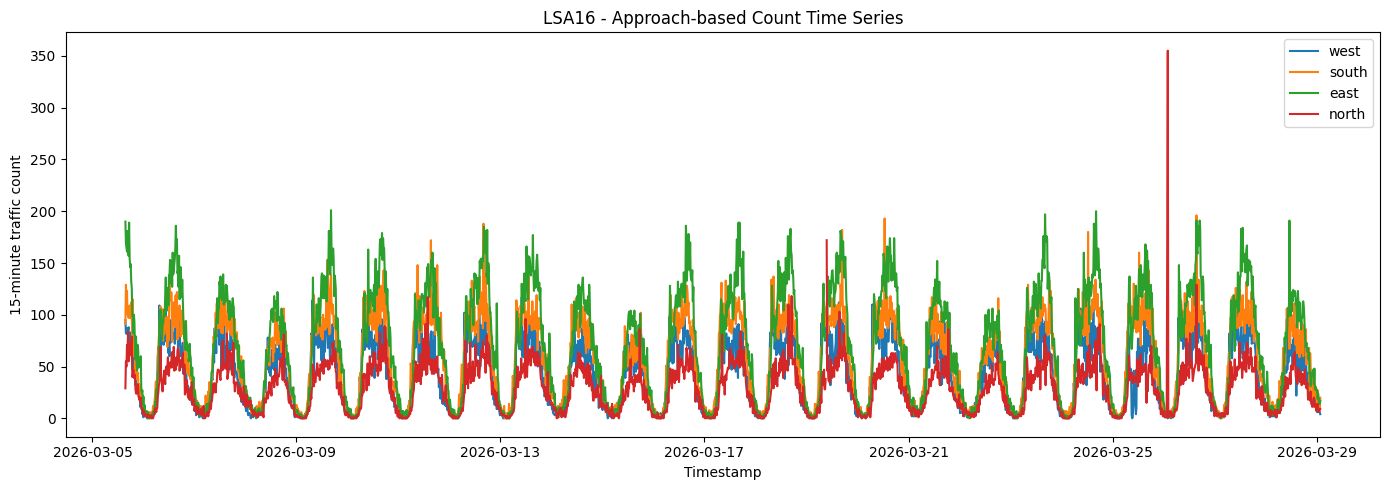

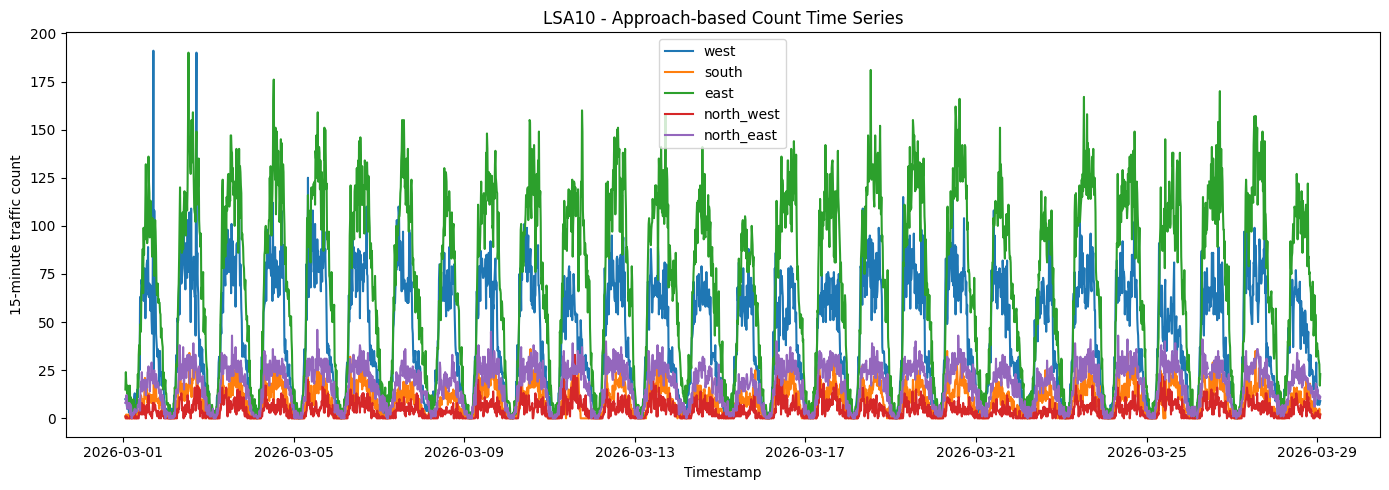

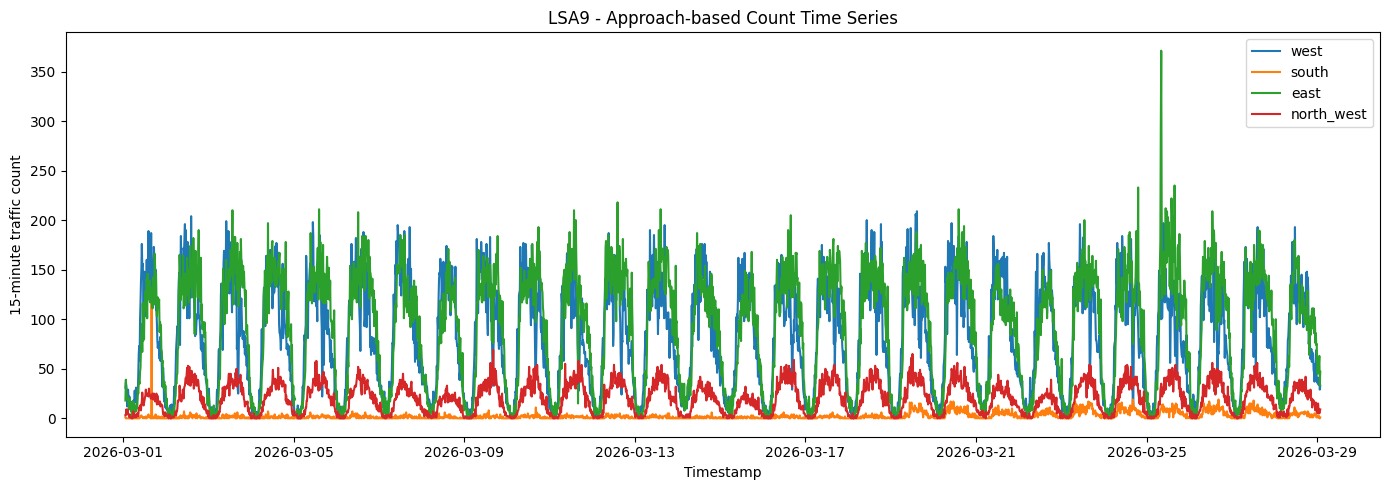

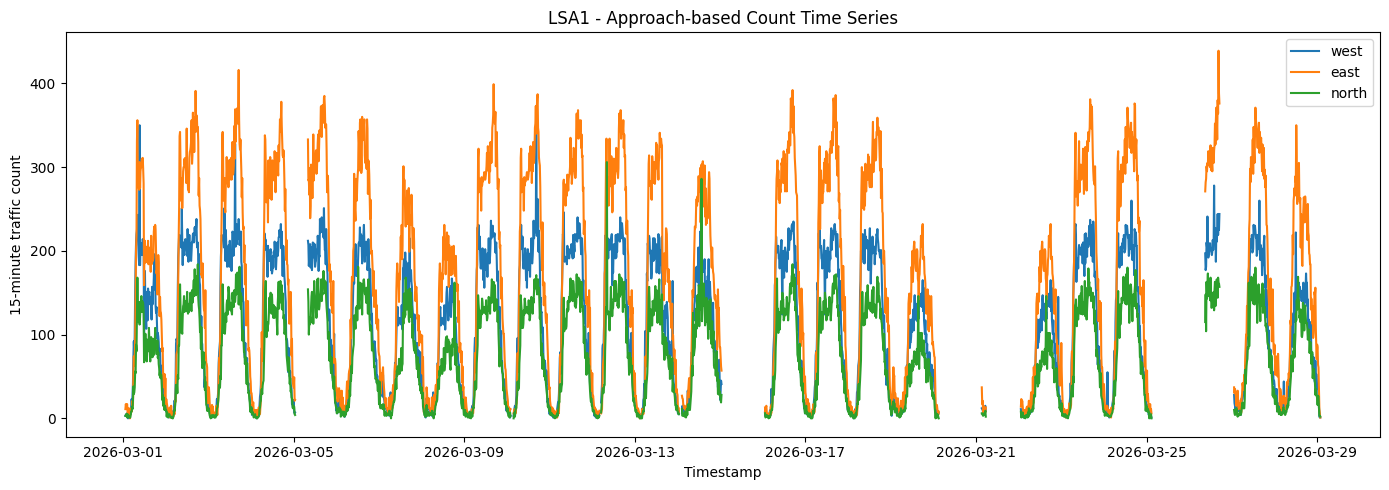

In [10]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# PATHS
# ============================================================

BASE_DIR = Path(r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\LSTM_Model")
APPROACH_CSV = BASE_DIR / "approach_counts_15min.csv"

# ============================================================
# LOAD
# ============================================================

approach_df = pd.read_csv(APPROACH_CSV)
approach_df["timestamp_berlin"] = pd.to_datetime(approach_df["timestamp_berlin"], errors="coerce")

LSA_COLUMNS = {
    "LSA16": [
        "LD-LSA16_west_count",
        "LD-LSA16_south_count",
        "LD-LSA16_east_count",
        "LD-LSA16_north_count",
    ],
    "LSA10": [
        "LD-LSA10_west_count",
        "LD-LSA10_south_count",
        "LD-LSA10_east_count",
        "LD-LSA10_north_west_count",
        "LD-LSA10_north_east_count",
    ],
    "LSA9": [
        "LD-LSA9_west_count",
        "LD-LSA9_south_count",
        "LD-LSA9_east_count",
        "LD-LSA9_north_west_count",
    ],
    "LSA1": [
        "LD-LSA1_west_count",
        "LD-LSA1_east_count",
        "LD-LSA1_north_count",
    ],
}

for lsa_name, cols in LSA_COLUMNS.items():
    existing_cols = [c for c in cols if c in approach_df.columns]

    plt.figure(figsize=(14, 5))
    for col in existing_cols:
        short_name = col.replace(f"LD-{lsa_name}_", "").replace("_count", "")
        plt.plot(approach_df["timestamp_berlin"], approach_df[col], label=short_name)

    plt.title(f"{lsa_name} - Approach-based Count Time Series")
    plt.xlabel("Timestamp")
    plt.ylabel("15-minute traffic count")
    plt.legend()
    plt.tight_layout()
    plt.show()

**Visualization of approach-based traffic time series**

The time series plots illustrate the temporal evolution of aggregated 15-minute traffic counts for each approach at the analyzed intersections. The results show clear and consistent daily patterns across all LSAs, characterized by low traffic volumes during nighttime and pronounced increases during daytime hours.

For all intersections, recurrent daily cycles can be observed, indicating stable traffic demand patterns. Morning and evening peak periods are visible, with the magnitude and timing varying depending on the intersection and approach direction. In particular, the east and west approaches generally exhibit higher traffic volumes, reflecting the dominant corridor flow.

Occasional sharp spikes are visible in some time series, for example at LSA16 and LSA9. These isolated peaks are likely caused by measurement anomalies or short-term disturbances rather than typical traffic behavior. Since these events occur infrequently and do not affect the overall pattern, they do not significantly impact the suitability of the dataset for modeling.

In addition, some gaps and missing values can be observed, especially for LSA1, indicating incomplete data availability for certain periods. This reflects real-world data limitations and is addressed during preprocessing.

Overall, the time series confirm that the aggregated detector data capture realistic traffic dynamics and are suitable for further analysis and forecasting.

**3. Average daily profiles for morning and evening peak identification**
This step computes mean 15-minute traffic profiles by time of day for each approach. The resulting profiles help identify recurring morning and evening peak periods.

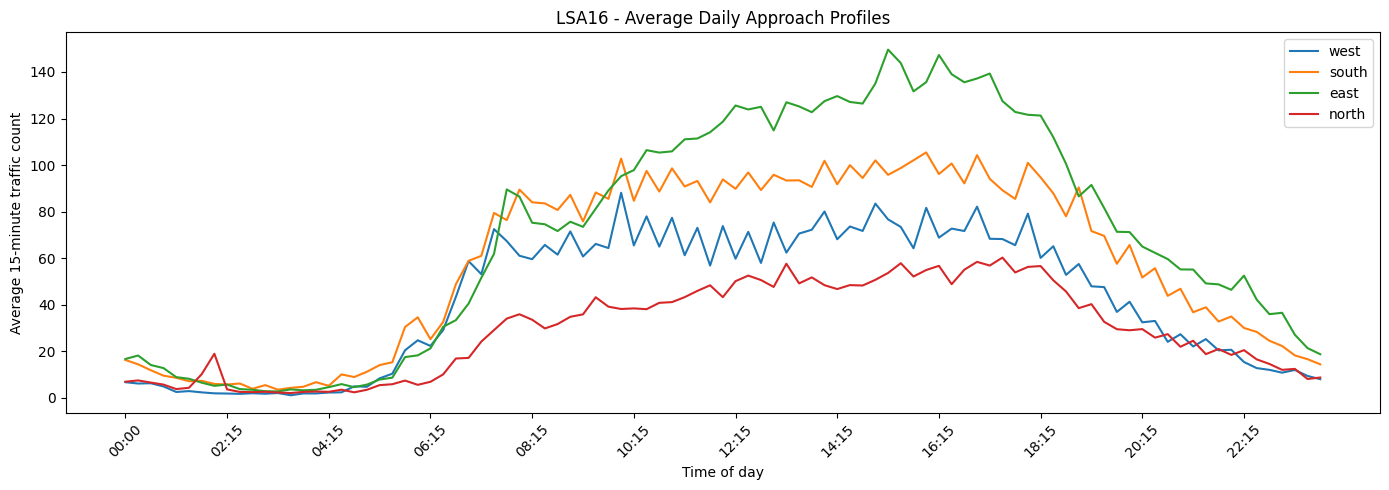

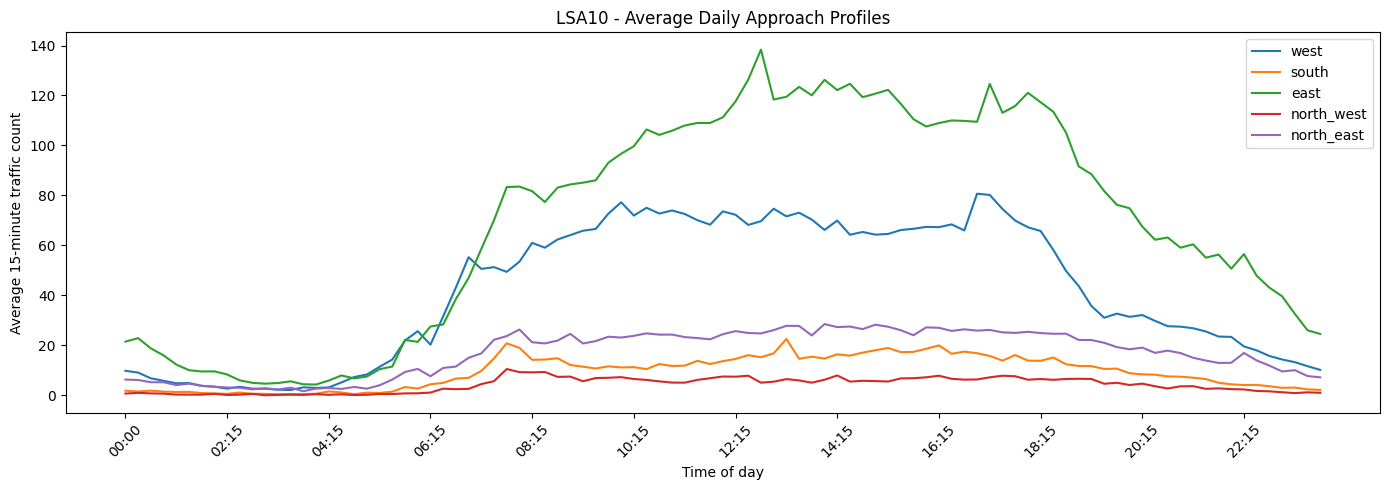

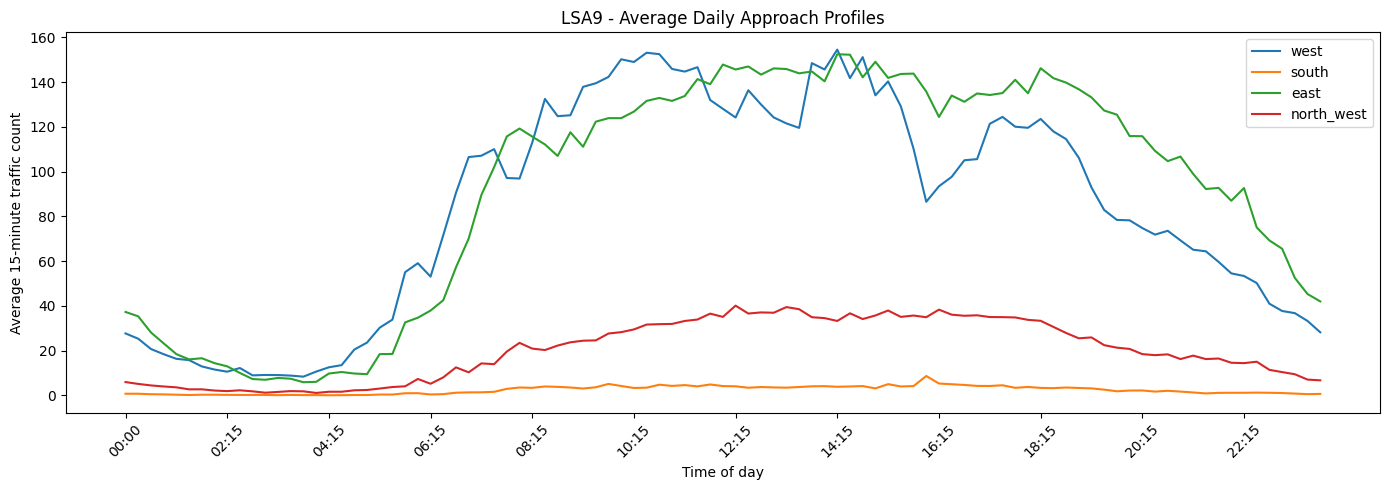

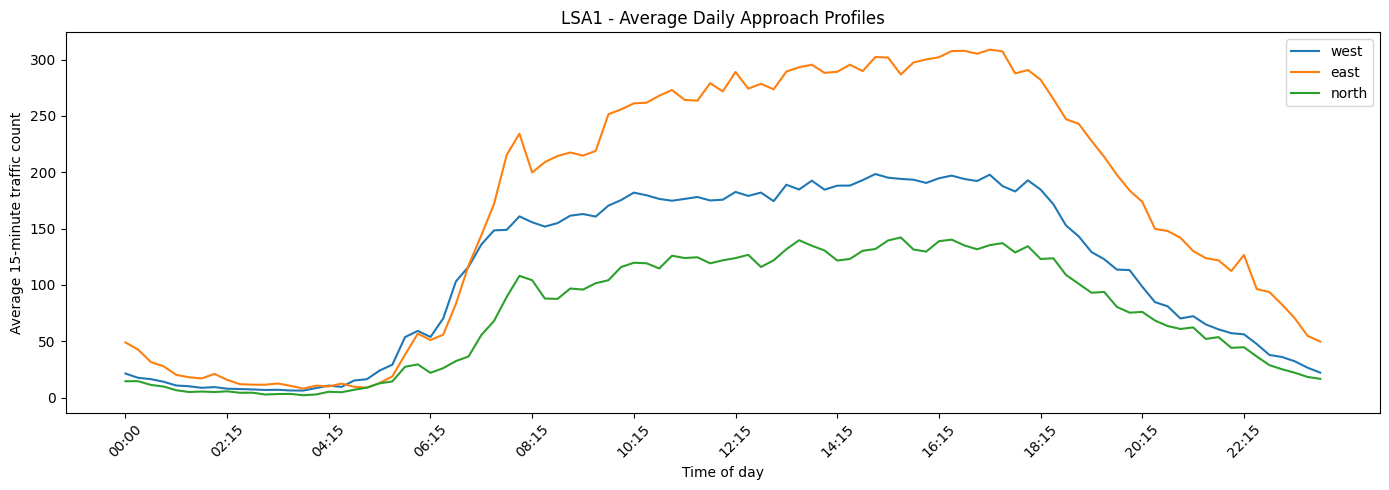

In [11]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# PATHS
# ============================================================

BASE_DIR = Path(r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\LSTM_Model")
APPROACH_CSV = BASE_DIR / "approach_counts_15min.csv"

# ============================================================
# LOAD
# ============================================================

approach_df = pd.read_csv(APPROACH_CSV)
approach_df["timestamp_berlin"] = pd.to_datetime(approach_df["timestamp_berlin"], errors="coerce")
approach_df["time_15min"] = approach_df["timestamp_berlin"].dt.strftime("%H:%M")

LSA_COLUMNS = {
    "LSA16": [
        "LD-LSA16_west_count",
        "LD-LSA16_south_count",
        "LD-LSA16_east_count",
        "LD-LSA16_north_count",
    ],
    "LSA10": [
        "LD-LSA10_west_count",
        "LD-LSA10_south_count",
        "LD-LSA10_east_count",
        "LD-LSA10_north_west_count",
        "LD-LSA10_north_east_count",
    ],
    "LSA9": [
        "LD-LSA9_west_count",
        "LD-LSA9_south_count",
        "LD-LSA9_east_count",
        "LD-LSA9_north_west_count",
    ],
    "LSA1": [
        "LD-LSA1_west_count",
        "LD-LSA1_east_count",
        "LD-LSA1_north_count",
    ],
}

for lsa_name, cols in LSA_COLUMNS.items():
    existing_cols = [c for c in cols if c in approach_df.columns]

    profile = (
        approach_df.groupby("time_15min")[existing_cols]
        .mean()
        .reset_index()
    )

    plt.figure(figsize=(14, 5))
    for col in existing_cols:
        short_name = col.replace(f"LD-{lsa_name}_", "").replace("_count", "")
        plt.plot(profile["time_15min"], profile[col], label=short_name)

    tick_idx = range(0, len(profile), 8)  # every 2 hours
    plt.xticks(
        ticks=tick_idx,
        labels=profile["time_15min"].iloc[list(tick_idx)],
        rotation=45
    )

    plt.title(f"{lsa_name} - Average Daily Approach Profiles")
    plt.xlabel("Time of day")
    plt.ylabel("Average 15-minute traffic count")
    plt.legend()
    plt.tight_layout()
    plt.show()

**Average daily approach profiles and peak identification**

The average daily profiles represent the mean traffic counts for each 15-minute interval across all available days. These profiles provide a smoothed representation of recurring daily traffic patterns and enable the identification of typical peak periods.

Across all intersections, clear morning and evening peaks are observed. Traffic demand generally begins to increase around 06:00, reaches a first peak during the morning hours, and remains relatively high throughout midday. A second peak is visible in the late afternoon or early evening, followed by a gradual decline toward nighttime levels.

The magnitude and distribution of traffic vary between approaches. At LSA16 and LSA10, the east approach shows the highest traffic volumes, indicating its importance as a main corridor direction. Similarly, at LSA9 and LSA1, the east and west approaches dominate, while north and south approaches exhibit lower traffic levels.

The profiles also highlight directional imbalances, where certain approaches consistently carry higher traffic loads. These differences are important for understanding traffic flow distribution and are valuable inputs for the forecasting model.

Overall, the average daily profiles confirm the presence of stable and interpretable traffic patterns, which are well suited for short-term prediction using LSTM models.

**4. Morning and evening peak windows**
This step focuses on the main traffic peak periods in order to compare directional demand patterns during the morning and evening hours.

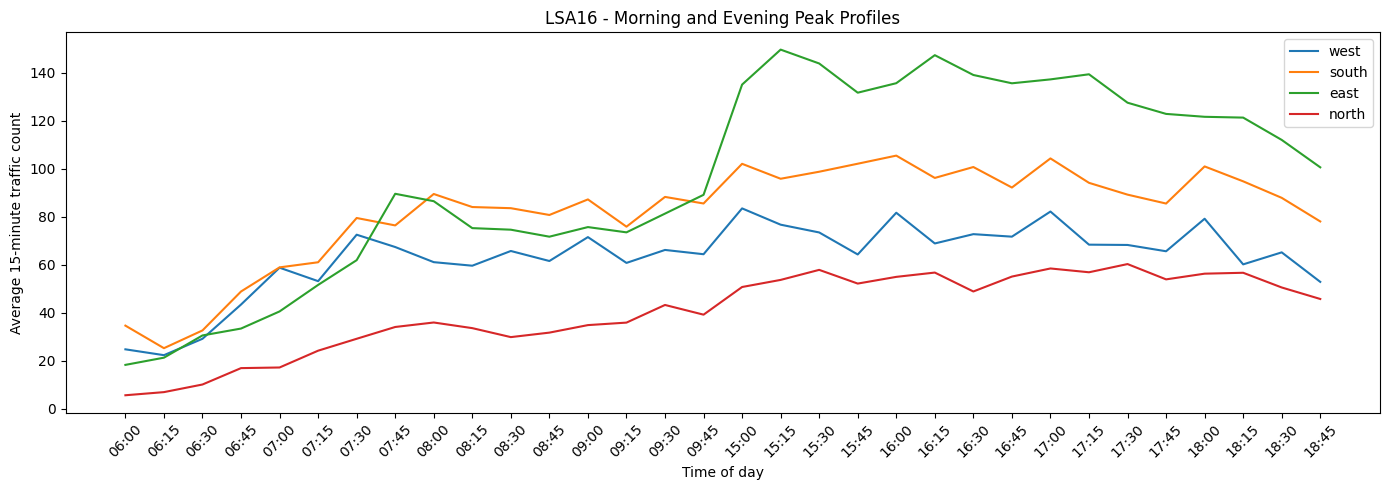

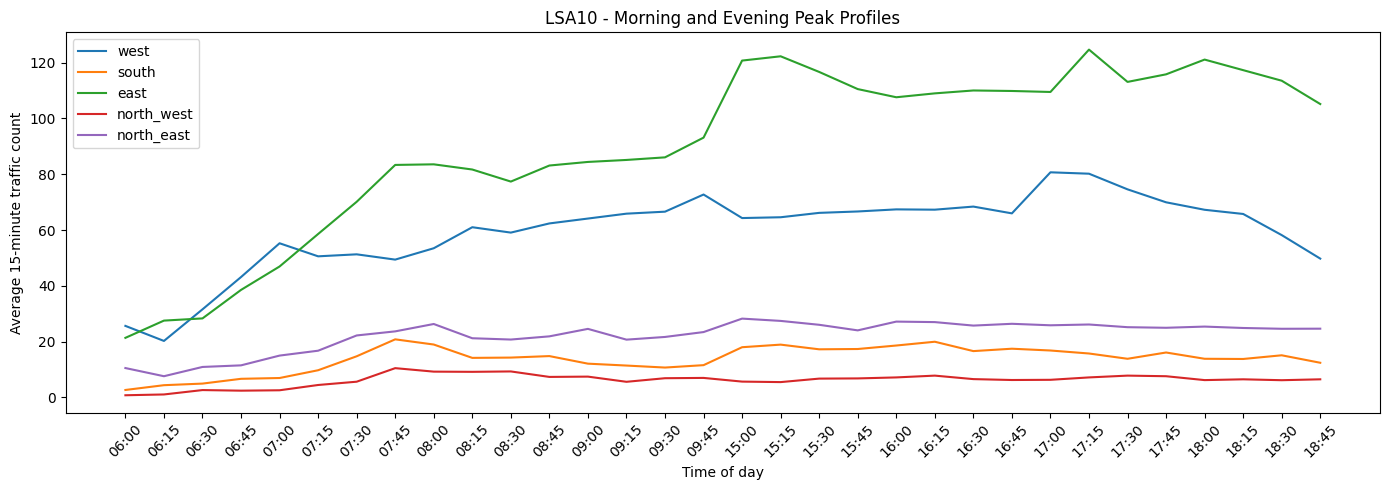

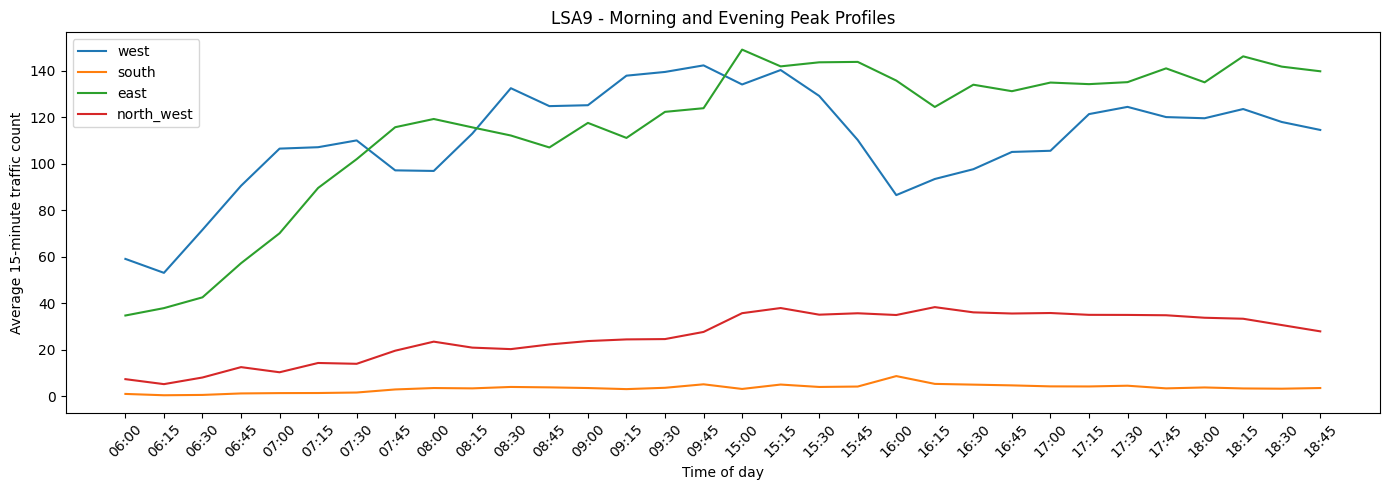

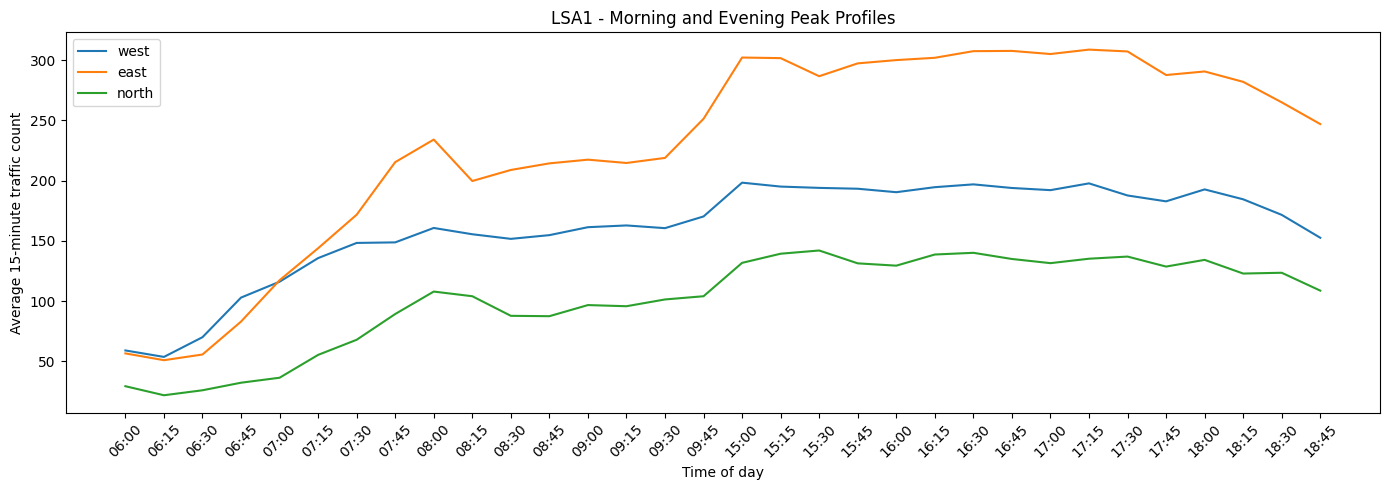

In [12]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# PATHS
# ============================================================

BASE_DIR = Path(r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\LSTM_Model")
APPROACH_CSV = BASE_DIR / "approach_counts_15min.csv"

# ============================================================
# LOAD
# ============================================================

approach_df = pd.read_csv(APPROACH_CSV)
approach_df["timestamp_berlin"] = pd.to_datetime(approach_df["timestamp_berlin"], errors="coerce")
approach_df["time_15min"] = approach_df["timestamp_berlin"].dt.strftime("%H:%M")

LSA_COLUMNS = {
    "LSA16": [
        "LD-LSA16_west_count",
        "LD-LSA16_south_count",
        "LD-LSA16_east_count",
        "LD-LSA16_north_count",
    ],
    "LSA10": [
        "LD-LSA10_west_count",
        "LD-LSA10_south_count",
        "LD-LSA10_east_count",
        "LD-LSA10_north_west_count",
        "LD-LSA10_north_east_count",
    ],
    "LSA9": [
        "LD-LSA9_west_count",
        "LD-LSA9_south_count",
        "LD-LSA9_east_count",
        "LD-LSA9_north_west_count",
    ],
    "LSA1": [
        "LD-LSA1_west_count",
        "LD-LSA1_east_count",
        "LD-LSA1_north_count",
    ],
}

PEAK_TIMES = [
    "06:00", "06:15", "06:30", "06:45",
    "07:00", "07:15", "07:30", "07:45",
    "08:00", "08:15", "08:30", "08:45",
    "09:00", "09:15", "09:30", "09:45",
    "15:00", "15:15", "15:30", "15:45",
    "16:00", "16:15", "16:30", "16:45",
    "17:00", "17:15", "17:30", "17:45",
    "18:00", "18:15", "18:30", "18:45",
]

for lsa_name, cols in LSA_COLUMNS.items():
    existing_cols = [c for c in cols if c in approach_df.columns]

    profile = (
        approach_df.groupby("time_15min")[existing_cols]
        .mean()
        .reset_index()
    )

    profile = profile[profile["time_15min"].isin(PEAK_TIMES)].reset_index(drop=True)

    plt.figure(figsize=(14, 5))
    for col in existing_cols:
        short_name = col.replace(f"LD-{lsa_name}_", "").replace("_count", "")
        plt.plot(profile["time_15min"], profile[col], label=short_name)

    plt.xticks(rotation=45)
    plt.title(f"{lsa_name} - Morning and Evening Peak Profiles")
    plt.xlabel("Time of day")
    plt.ylabel("Average 15-minute traffic count")
    plt.legend()
    plt.tight_layout()
    plt.show()

**Morning and evening peak window analysis**

The peak window plots focus on selected morning and afternoon time periods in order to examine directional traffic patterns in greater detail. Unlike the full daily profiles, these plots isolate typical commuting hours and allow a closer inspection of traffic dynamics during high-demand periods.

The results show that traffic demand gradually increases during the morning period and remains relatively high throughout midday and the afternoon. Instead of sharp, isolated peaks at a specific time (e.g., exactly at 16:00), the traffic patterns exhibit broad peak periods. This indicates that traffic demand is distributed over a longer time interval rather than concentrated in a single 15-minute period.

For most intersections, especially LSA16, LSA10, and LSA9, the afternoon traffic demand reaches a plateau between approximately 14:00 and 17:30. This behavior reflects typical urban traffic conditions, where congestion builds up gradually and remains sustained over several hours due to overlapping travel purposes such as commuting, shopping, and local trips.

At LSA1, a similar pattern is observed, although the magnitude of traffic is higher and more variable. The east approach consistently shows the highest demand, confirming its role as a dominant corridor direction.

Overall, the absence of a single sharp peak does not indicate an issue in the data. Instead, it reflects realistic traffic behavior, where peak demand is spread over extended periods rather than occurring at a single time point.

****
The observed peak periods do not appear as sharp spikes at a single time step but rather as extended high-demand intervals. This is due to both the averaging process across multiple days and the inherent nature of urban traffic, where peak demand is distributed over longer time windows instead of occurring at a single moment.
****